In [1]:
from datascience import *
import numpy as np
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
plt.rcParams["patch.force_edgecolor"] = True

import seaborn as sns

<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

# Tables and Filtering

## SAT Data
Today we will be working with a dataset showing aggregated (average) SAT scores by state ([source 1](https://commonwealthfoundation.org/2014/12/22/sat-scores-by-state-2014/), [source 2](https://reports.collegeboard.org/sat-suite-program-results/data-archive)).

**Note**: This data is from 2014, so the total score is out of 2400 (over three sections each out of 800) instead of 1600.

In [2]:
sat = Table.read_table('data/sat2014-lecture.csv')
sat

State,Participation Rate,Critical Reading,Math,Writing
Alabama,6.7,547,538,532
Alaska,54.2,507,503,475
Arizona,36.4,522,525,500
Arkansas,4.2,573,571,554
California,60.3,498,510,496
Colorado,14.3,582,586,567
Connecticut,88.4,507,510,508
Delaware,100,456,459,444
District of Columbia,100,440,438,431
Florida,72.2,491,485,472


In [3]:
sat = sat.with_columns(
    'Combined',
    sat.column('Critical Reading') + \
        sat.column('Math') + \
        sat.column('Writing')
)

In [4]:
sat.sort("State", descending=True).take(np.arange(5))

State,Participation Rate,Critical Reading,Math,Writing,Combined
Wyoming,3.3,590,599,573,1762
Wisconsin,3.9,596,608,578,1782
West Virginia,14.8,517,505,500,1522
Washington,63.1,510,518,491,1519
Virginia,73.1,518,515,497,1530


## `.where`

We've already seen how we can use `tbl.where()` to find rows that _exactly_ match what we're looking for. For example:

In [5]:
sat.where('State', 'California')

State,Participation Rate,Critical Reading,Math,Writing,Combined
California,60.3,498,510,496,1504


But `tbl.where` is also capable of so much more! The second argument in `.where` can accept a **predicate**, which tells Python what condition to match rows on. See the [Data 6 Python Reference](https://data6.org/notes/reference)

In [6]:
sat.where("Combined", are.above(1800))

State,Participation Rate,Critical Reading,Math,Writing,Combined
Illinois,4.6,599,616,587,1802
North Dakota,2.3,612,620,584,1816


Note that `are.equal_to(z)` is the same as just passing in `z` itself as the second argument.

In [7]:
sat.where("State", are.containing("Dakota"))

State,Participation Rate,Critical Reading,Math,Writing,Combined
North Dakota,2.3,612,620,584,1816
South Dakota,2.9,604,609,579,1792


In [8]:
sat.where("Math", are.between(580, 600))

State,Participation Rate,Critical Reading,Math,Writing,Combined
Colorado,14.3,582,586,567,1735
Kansas,5.3,591,596,566,1753
Kentucky,4.6,589,585,572,1746
Missouri,4.2,595,597,579,1771
Nebraska,3.7,589,587,569,1745
Wyoming,3.3,590,599,573,1762


### Method Chaining: Multiple Conditions

We can match rows to multiple conditions/predicates by chaining `where` method calls together. For example, we can look for states where the participation rate is above 20% and the average combined SAT score is above 1500.

In [9]:
sat.where("Participation Rate", are.above(20)).where("Combined", are.above(1500)) # Filter the `sat` table to find states where participation is above 20% and combined score is above 1500

State,Participation Rate,Critical Reading,Math,Writing,Combined
Arizona,36.4,522,525,500,1547
California,60.3,498,510,496,1504
Connecticut,88.4,507,510,508,1525
Massachusetts,84.1,516,531,509,1556
New Hampshire,70.3,524,530,512,1566
New Jersey,79.3,501,523,502,1526
Oregon,47.9,523,522,499,1544
Vermont,63.1,522,525,507,1554
Virginia,73.1,518,515,497,1530
Washington,63.1,510,518,491,1519


In [10]:
# better formatting (note parentheses)
(
    sat.where("Participation Rate", are.above(20))
        .where("Combined", are.above(1500))
)

State,Participation Rate,Critical Reading,Math,Writing,Combined
Arizona,36.4,522,525,500,1547
California,60.3,498,510,496,1504
Connecticut,88.4,507,510,508,1525
Massachusetts,84.1,516,531,509,1556
New Hampshire,70.3,524,530,512,1566
New Jersey,79.3,501,523,502,1526
Oregon,47.9,523,522,499,1544
Vermont,63.1,522,525,507,1554
Virginia,73.1,518,515,497,1530
Washington,63.1,510,518,491,1519


**Task**

Filter the `sat` table to find states where participation is below 10% and combined score is between 1200 and 1400.

In [11]:
...

Ellipsis

We can have multiple different values to match to if we put then in an array and then use `are.contained_in`.

In [12]:
deep_south = np.array(['Alabama', 'Georgia',
                       'Louisiana', 'Mississippi',
                       'South Carolina'])

**Task**

Filter the `sat` table to include only the states listed in the `deep_south` array.

In [13]:
...

Ellipsis

**Just for fun:** consider the scatter plot of all states' participation rates and combined SAT scores. Does this scatter plot imply that **lower participation _causes_ higher SAT scores? If not, what might be going on here?**

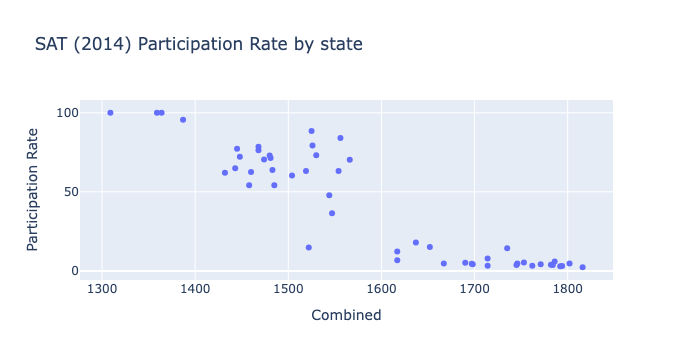

In [14]:
import plotly.express as px

px.scatter(data_frame = sat.to_df(), 
           x = 'Combined', 
           y = 'Participation Rate', 
           hover_data = {'State': True},
           title = 'SAT (2014) Participation Rate by state')

<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

# Booleans

In [15]:
3 > 1 + 1

True

In [16]:
3 < -1 * 2

False

In [17]:
1 < 1 + 1 < 3

True

In [18]:
# is age at least age_limit?
age_limit = 21
age = 18
age >= age_limit

False

In [19]:
# is password_guess equal to true_password?
true_password = 'qwerty1093x!'
password_guess = 'QWERTY1093x!'
true_password == password_guess

False

## Comparison Operators

We want to make sure not to confuse `comparison` with `assignment` operators

In [20]:
# set x equal to 5
x = 5

In [21]:
# is x equal to 5?
x == 5

True

In [22]:
s = "Data " + "6"
s == "Data 6"

True

In [23]:
# valid. what does it do?
y = x == 5

In [24]:
x

5

In [25]:
y

True

## Comparison Across Types

In [26]:
17 == '17'

False

In [27]:
17 == 17.0

True

In [28]:
# Truthiness and Falsiness can be a bit odd
True == 1.0

True

In [29]:
False == 0

True

5 > True

In the above cell, the boolean value is being type cast into an integer value, 1!

In [30]:
int(True)

1

In [31]:
int(False)

0

Often though, we can't compare across types

In [32]:
banana = 10
'apple' >= banana

TypeError: '>=' not supported between instances of 'str' and 'int'

## Functions

### Create functions with a definition

```python
def functionname(Arguments_Parameters_Expressions_or_Values):  
    """docstring"""
      return return_expression
```

### **Task:** Create a function called `triple()` that takes an input `x`  and triples it.

In [33]:
def triple(x):
    """triples the input"""
    tripled_x = x * 3
    return tripled_x

In [34]:
triple(3)

9

In [35]:
num = 4

In [36]:
triple(num)

12

In [37]:
triple(num * 5)

60

### Return values

Functions are not required to "`return`" anything. If a function doesn’t explicitly return anything, it will return `None` (like `print`).

Run the following cell and see if you can decipher what is happening.

In [38]:
def add_and_print(a, b):
    total = a + b
    print(total)

total = add_and_print(3, 4)
print("the sum of 3 and 4 is", total)

7
the sum of 3 and 4 is None


### Return statements exit a function

Once we reach a statement with a `return` keyword, our function is done running. Nothing after this **return statement** is run.

Below, `odd` checks if a number is even or odd by checking if the remainder modulo 2 is equal to (`==`) 1. If it is not, then it is zero, meaning that the number is divisible by two (and therefore even).

In [39]:
def odd(n):
    return n % 2 == 1
    print("this will never be printed!")

In [40]:
odd(15)

True

In [41]:
odd(2)

False

In [42]:
sat.show(4)

State,Participation Rate,Critical Reading,Math,Writing,Combined
Alabama,6.7,547,538,532,1617
Alaska,54.2,507,503,475,1485
Arizona,36.4,522,525,500,1547
Arkansas,4.2,573,571,554,1698


In [43]:
def avg_section(x,y, z):
    return (x + y + z) / 3

In [47]:
sat.with_column("Average Section Score", 
                sat.apply(avg_section, 'Critical Reading', 'Math', 'Writing'))

State,Participation Rate,Critical Reading,Math,Writing,Combined,Average Section Score
Alabama,6.7,547,538,532,1617,539
Alaska,54.2,507,503,475,1485,495
Arizona,36.4,522,525,500,1547,515.667
Arkansas,4.2,573,571,554,1698,566
California,60.3,498,510,496,1504,501.333
Colorado,14.3,582,586,567,1735,578.333
Connecticut,88.4,507,510,508,1525,508.333
Delaware,100,456,459,444,1359,453
District of Columbia,100,440,438,431,1309,436.333
Florida,72.2,491,485,472,1448,482.667


### Strings

In [ ]:
s = 'JuNiOR12'

# space to try out string methods

In [48]:
'berkeley' in 'uc berkeley'

True

## Scope

In [ ]:
def even(n):
    print("value of n", n)
    return n % 2 == 0

In [ ]:
even(15)
print("n outside function", n)

From within a function, can find and read values of names defined **outside** of function scope